In [2]:
import os
import cv2
import numpy as np

def load_frames(video_path):

    frames = []
    cap = cv2.VideoCapture(video_path)

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.resize(frame, (224,224))

        # Normalize here
        frame = frame.astype(np.float32) / 255.0

        frames.append(frame)

    cap.release()

    return frames

In [3]:
import os
import kagglehub

# 1. Download/Get the path
path = kagglehub.dataset_download("mahmoudosamahassan/shop-dataset")
print("Path to dataset files:", path)

# 2. Define the subfolder paths using the 'path' variable
# Note: This dataset has a nested "Shop DataSet" folder inside it
DATASET_PATH = os.path.join(path, "Shop DataSet")

non_shop_path = os.path.join(DATASET_PATH, "non shop lifters")
shop_path = os.path.join(DATASET_PATH, "shop lifters")

# 3. Quick sanity check
if os.path.exists(non_shop_path):
    print(f"Found {len(os.listdir(non_shop_path))} videos in: {non_shop_path}")
else:
    # If the creator didn't nest it, try the root 'path' directly
    print("Trying root path instead...")
    non_shop_path = os.path.join(path, "non shop lifters")
    shop_path = os.path.join(path, "shop lifters")

    if os.path.exists(non_shop_path):
         print(f"Found videos in: {non_shop_path}")
    else:
         print("Error: Folders 'non shop lifters' or 'shop lifters' not found in download.")

Using Colab cache for faster access to the 'shop-dataset' dataset.
Path to dataset files: /kaggle/input/shop-dataset
✅ Found 531 videos in: /kaggle/input/shop-dataset/Shop DataSet/non shop lifters


In [4]:
non_shop_files = [os.path.join(non_shop_path, f) for f in os.listdir(non_shop_path) if f.endswith('.mp4')]
shop_files = [os.path.join(shop_path, f) for f in os.listdir(shop_path) if f.endswith('.mp4')]

print(f"Total Non-Shoplifting videos: {len(non_shop_files)}")
print(f"Total Shoplifting videos: {len(shop_files)}")

Total Non-Shoplifting videos: 531
Total Shoplifting videos: 324


In [6]:
def load_and_sample_video(video_path, target_frames=20, size=(64, 64)):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, size)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame / 255.0)
    cap.release()

    if len(frames) == 0:
        return np.zeros((target_frames, size[0], size[1], 3))

    indices = np.linspace(0, len(frames) - 1, target_frames).astype(int)
    sampled_frames = [frames[i] for i in indices]
    return np.array(sampled_frames)

def data_generator(non_shop_files, shop_files, batch_size=4):
    all_files = [(f, 0) for f in non_shop_files] + [(f, 1) for f in shop_files]
    while True:
        np.random.shuffle(all_files)
        for i in range(0, len(all_files), batch_size):
            batch_data = all_files[i : i + batch_size]
            X_batch, Y_batch = [], []
            for file_path, label in batch_data:
                frames = load_and_sample_video(file_path)
                X_batch.append(frames)
                Y_batch.append(label)
            yield np.array(X_batch), np.array(Y_batch)

In [8]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models


model = models.Sequential([

    layers.TimeDistributed(layers.Conv2D(16, (3, 3), padding='same', activation='relu'), input_shape=(20, 64, 64, 3)),
    layers.TimeDistributed(layers.MaxPooling2D((2, 2))),
    layers.TimeDistributed(layers.Conv2D(32, (3, 3), padding='same', activation='relu')),
    layers.TimeDistributed(layers.MaxPooling2D((2, 2))),
    layers.TimeDistributed(layers.Flatten()),


    layers.LSTM(64),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 64, 64, 16) │           448 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 32, 32, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 20, 32, 32, 32) │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 20, 16, 16, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 20, 8192)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     2,113,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,120,993 (8.09 MB)

 Trainable params: 2,120,993 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 1. Prepare the feeding mechanism
BATCH_SIZE = 4
train_gen = data_generator(non_shop_files, shop_files, batch_size=BATCH_SIZE)

# 2. Calculate how many batches make one full cycle
total_videos = len(non_shop_files) + len(shop_files)
steps_per_epoch = total_videos // BATCH_SIZE

# 3. Set up the Early Stopping "Safety Net"
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=5,          # Stops if the model doesn't improve for 5 straight epochs
    restore_best_weights=True
)

# 4. Re-compile with a stable learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Execute Training
print(f"Training started for {total_videos} videos...")
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=50,
    callbacks=[early_stop]
)

Training started for 855 videos...
Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.6080 - loss: 0.6611
Epoch 2/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - accuracy: 0.6639 - loss: 0.6001
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 299s 1s/step - accuracy: 0.8308 - loss: 0.4356
Epoch 4/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.8484 - loss: 0.3902
Epoch 5/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.9060 - loss: 0.2788
Epoch 6/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - accuracy: 0.9389 - loss: 0.2134
Epoch 7/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 301s 1s/step - accuracy: 0.9589 - loss: 0.1414
Epoch 8/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.9683 - loss: 0.1047
Epoch 9/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - accuracy: 0.9988 - loss: 0.0249
Epoch 10/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.9694 - loss: 0.0768
Epoch 11/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.9894 - loss: 0.0622
Epoch 

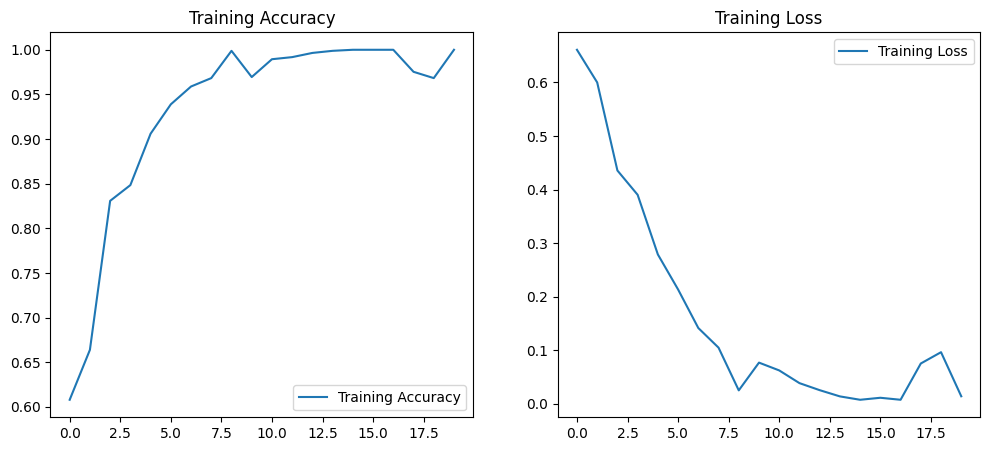

In [13]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    loss = history.history['loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.title('Training Accuracy')
    plt.legend(loc='lower right')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.title('Training Loss')
    plt.legend(loc='upper right')

    plt.show()

plot_history(history)

Loading 50 test videos... please wait.
Generating predictions...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step


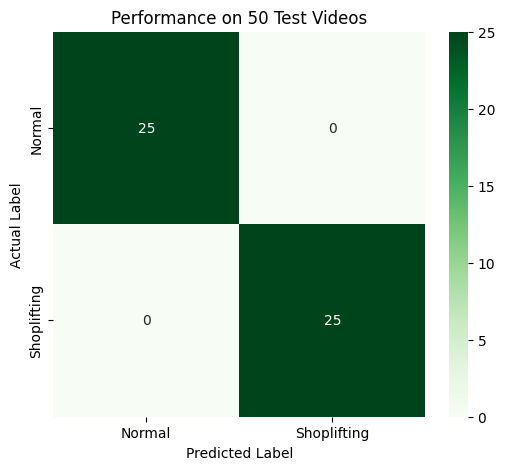


--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        25
 Shoplifting       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [15]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select 25 videos from each category for testing
test_files = non_shop_files[:25] + shop_files[:25]
test_labels = [0]*25 + [1]*25

X_test = []
print("Loading 50 test videos... please wait.")

for f in test_files:
    # Use the same preprocessing function we defined earlier
    frames = load_and_sample_video(f)
    X_test.append(frames)

X_test = np.array(X_test)
Y_test = np.array(test_labels)

# 2. Predict using the trained model
print("Generating predictions...")
predictions = model.predict(X_test)
# Convert probabilities (e.g. 0.8) to binary labels (1)
predictions_binary = (predictions > 0.5).astype(int)

# 3. Visualize Results with a Confusion Matrix
cm = confusion_matrix(Y_test, predictions_binary)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Shoplifting'],
            yticklabels=['Normal', 'Shoplifting'])
plt.title('Performance on 50 Test Videos')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Detailed Metrics
print("\n--- Classification Report ---")
print(classification_report(Y_test, predictions_binary, target_names=['Normal', 'Shoplifting']))

In [16]:
# Save the model in the standard Keras format
model.save('shoplifting_detector_model.h5')

print("Model saved successfully as shoplifting_detector_model.h5")
print("You can find it in the 'Output' section of the right-hand sidebar.")

✅ Model saved successfully as shoplifting_detector_model.h5
You can find it in the 'Output' section of the right-hand sidebar.
